# ***Mounting Drive***

In [ ]:
from google.colab import drive
import os
import warnings
warnings.filterwarnings('ignore')

drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/! Coding Workspace/2025_HOLOGY')
print(os.getcwd())

Mounted at /content/drive
/content/drive/MyDrive/! Coding Workspace/2025_HOLOGY


# ***Download Data***
---

In [ ]:
import os
from google.colab import userdata

# Get Kaggle credentials from Colab secrets
kaggle_json = userdata.get('KAGGLE_JSON')

# Create the .kaggle directory and kaggle.json file
!mkdir -p ~/.kaggle
with open('/root/.kaggle/kaggle.json', 'w') as f:
    f.write(kaggle_json)

# Set file permissions
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle credentials set up successfully.")

Kaggle credentials set up successfully.


In [ ]:
!kaggle competitions download -c penyisihan-hology-8-0-2025-data-mining -p ./data

 88% 184M/209M [00:01<00:00, 78.4MB/s]
100% 209M/209M [00:01<00:00, 140MB/s] 


In [ ]:
import zipfile

# Extract dataset
with zipfile.ZipFile('./data/penyisihan-hology-8-0-2025-data-mining.zip', 'r') as zip_ref:
    zip_ref.extractall('./data/')

# ***EDA***
---

In [5]:
import os
import json
import pandas as pd
from matplotlib import pyplot as plt

label_dir = './data/train/labels/'
results = []
json_files = [f for f in os.listdir(label_dir) if f.endswith('.json')]

# Iterate through each JSON file
for filename in json_files:
    filepath = os.path.join(label_dir, filename)
    with open(filepath, 'r') as f:
        data = json.load(f)

    img_id = data.get('img_id')
    human_num = data.get('human_num')

    if img_id and human_num is not None:
        results.append({'img_id': img_id, 'human_num': human_num})

df_human_counts = pd.DataFrame(results)
print(f"\nTotal entries found: {len(df_human_counts)}")


Total entries found: 1900


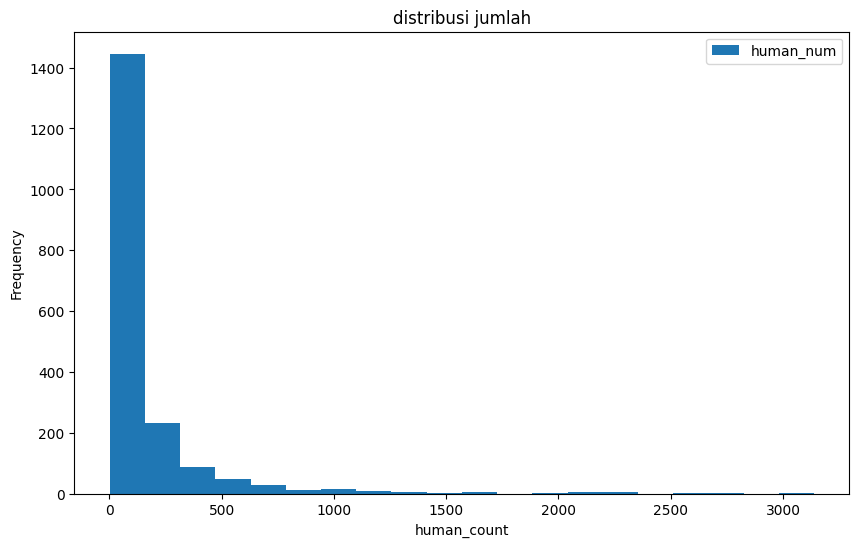

In [11]:
df_human_counts.plot(kind='hist', x='img_id', y='human_num',
                     title='distribusi jumlah' ,figsize=(10, 6),
                     xlabel = 'human_count', bins=20)
plt.show()

Histogram di atas menunjukkan distribusi dari variabel `human_count` dalam dataset. Sumbu-X merepresentasikan jumlah manusia dalam satu gambar, sedangkan Sumbu-Y menunjukkan frekuensi atau berapa banyak gambar yang memiliki jumlah tersebut. Sebagian besar data terkonsentrasi pada nilai `human_count` yang rendah (sekitar 0-250). Ini terlihat dari bar tertinggi yang berada di sisi paling kiri. Artinya, **mayoritas gambar dalam dataset berisi kerumunan orang yang sedikit atau tidak padat.**

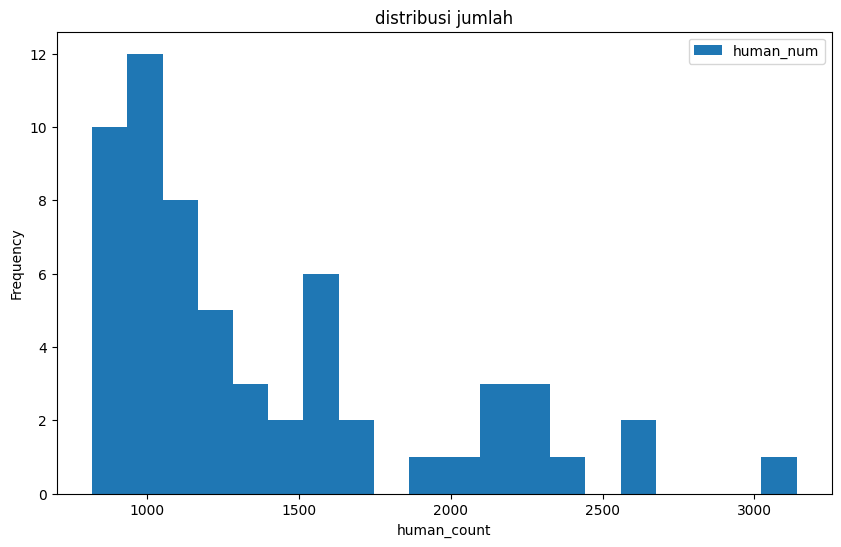

In [12]:
# tambahin label x dan y
df_human_counts[df_human_counts['human_num'] > 800].plot(kind='hist', x='img_id', y='human_num',
                                                         title='distribusi jumlah' ,figsize=(10, 6),
                                                         xlabel = 'human_count', bins=20)
plt.show()

# ***Preprocesing and Modelling***
---

Sebelum mulai kami menyiapkan fondasi dulu:

- mengimpor tool utama (NumPy, OpenCV, PyTorch, Albumentations, dll.)
- menetapkan SEED=42 agar hasil lebih konsisten
- mengaktifkan cuDNN benchmark untuk eksekusi lebih cepat (ukuran input relatif stabil)
- menata path (data/…, outputs/) dan membuat folder output bila belum ada
- memverifikasi keberadaan folder gambar & label agar salah path langsung terdeteksi

Tujuannya sederhana: memastikan proses training nanti rapi, cepat, dan mudah direproduksi.

In [15]:
import os, json, math, random, glob
from pathlib import Path
import numpy as np
import cv2
from tqdm import tqdm
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from scipy.spatial import cKDTree
import albumentations as A
from albumentations.pytorch import ToTensorV2
from scipy.ndimage import gaussian_filter

# Repro
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

# ==== Config ====
DATA_DIR = "./data"
IMG_DIR  = f"{DATA_DIR}/train/images"
LBL_DIR  = f"{DATA_DIR}/train/labels"
OUT_DIR  = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)

assert os.path.isdir(IMG_DIR) and os.path.isdir(LBL_DIR), "Pastikan folder data sesuai!"


## **PREPROCESSING**

Kami siapkan dua utilitas supaya data masuk pipeline dengan rapi dan konsisten:

- **`load_points_from_json(json_path)`**  
  Menormalkan berbagai skema anotasi titik menjadi `ndarray (N, 2)` bertipe `float32` dalam urutan `(x, y)`.  
  Mendukung kunci umum seperti `root.points`, `points`, `annotations`, `people`, `keypoints`, `dots`, atau langsung *top-level list*.  
  Menerima dua bentuk item: **list-of-dict** (`{"x":..,"y":..}`) dan **list-of-list/tuple** (`[x, y]`), dengan fallback `pos` / `point` / `pt`.  
  Jika tidak ada titik valid, fungsi mengembalikan array kosong `(0, 2)` agar tahap berikutnya tetap aman.

- **`list_pairs(img_dir, lbl_dir)`**  
  Membangun pasangan **(path_gambar, path_label_json)** berdasarkan **nama file yang sama**—hanya yang keduanya ada yang dipakai.  
  Output singkat (`len(pairs), pairs[:3]`) dipakai sebagai *sanity check* jumlah data dan struktur path.

> Catatan: koordinat diperlakukan sebagai `(x, y)` (kolom, baris). Jika ada dataset yang memakai `(row, col)`, lakukan konversi saat pembuatan density map.

In [16]:
import json
import numpy as np

def load_points_from_json(json_path: str):
    """
    Return: np.ndarray shape (N,2) float32 of (x,y).
    Mendukung beberapa skema:
      A) {"root":{"img_id": "...", "points": [{"x":..,"y":..}, ...]}}
      B) {"img_id":"...", "points":[{"x":..,"y":..}, ...]}
      C) {"img_id":"...", "points":[[x,y], [x,y], ...]}
      D) {"annotations":[{"x":..,"y":..}, ...]} atau {"people":[...]} (fallback)
    Bila tidak ada points valid -> array kosong.
    """
    with open(json_path, "r") as f:
        js = json.load(f)

    obj = js["root"] if isinstance(js, dict) and "root" in js else js

    # kandidat field yang mungkin berisi titik
    cand_keys = ["points", "annotations", "people", "keypoints", "dots"]
    pts = None
    for k in cand_keys:
        if isinstance(obj, dict) and k in obj:
            pts = obj[k]
            break

    if pts is None:
        # beberapa dataset menaruh langsung sebagai list di top-level
        if isinstance(obj, list):
            pts = obj
        else:
            return np.zeros((0,2), dtype=np.float32)

    arr = []
    # bentuk 1: list of dict {"x":..., "y":...}
    if isinstance(pts, list) and len(pts) > 0 and isinstance(pts[0], dict):
        for p in pts:
            try:
                x = float(p["x"]); y = float(p["y"])
                arr.append([x, y])
            except Exception:
                # coba variasi lain: {"pos":[x,y]} atau {"point":[x,y]}
                for alt in ("pos","point","pt"):
                    if alt in p and isinstance(p[alt], (list, tuple)) and len(p[alt])>=2:
                        arr.append([float(p[alt][0]), float(p[alt][1])])
                        break

    # bentuk 2: list of list/tuple [[x,y], ...]
    elif isinstance(pts, list) and len(pts) > 0 and isinstance(pts[0], (list, tuple)):
        for xy in pts:
            if len(xy) >= 2:
                arr.append([float(xy[0]), float(xy[1])])

    # kalau kosong / tidak valid
    if not arr:
        return np.zeros((0,2), dtype=np.float32)

    return np.asarray(arr, dtype=np.float32)


def list_pairs(img_dir, lbl_dir) -> List[Tuple[str, str]]:
    imgs = sorted(glob.glob(os.path.join(img_dir, "*.jpg")))
    pairs = []
    for ip in imgs:
        name = os.path.splitext(os.path.basename(ip))[0]
        jp = os.path.join(lbl_dir, f"{name}.json")
        if os.path.exists(jp):
            pairs.append((ip, jp))
    return pairs

pairs = list_pairs(IMG_DIR, LBL_DIR)
len(pairs), pairs[:3]


(1900,
 [('./data/train/images/1.jpg', './data/train/labels/1.json'),
  ('./data/train/images/10.jpg', './data/train/labels/10.json'),
  ('./data/train/images/100.jpg', './data/train/labels/100.json')])

### **Density Map**

---
**Geometry-Agnostic Kernel**
$$
F(x, y) = \sum_{i=1}^{N} \delta(x - x_i, y - y_i) * G_{\sigma}(x, y)
$$
Dimana:  
- $N$ = jumlah titik anotasi
- $(x_i, y_i)$ = koordinat titik anotasi ke-$i$
- $\delta(x - x_i, y - y_i)$ = fungsi delta 2D, bernilai 1 di posisi titik, 0 di tempat lain
- $G_{\sigma}(x, y)$ = kernel Gaussian 2D dengan standar deviasi tetap
- $\sigma$ = standar deviasi

In [19]:
FIXED_SIGMA = 15

def generate_density_map(image_shape, points):
    height, width = image_shape
    point_map = np.zeros((height, width), dtype=np.float32)

    # Looping setiap kamus 'point_dict' di dalam list 'points'
    for point_dict in points:
        try:
            # Ambil nilai x dan y dari kamus
            x = point_dict['x']
            y = point_dict['y']

            # Konversi ke integer dan cek batas
            x_int, y_int = int(x), int(y)
            if x_int < width and y_int < height:
                point_map[y_int, x_int] = 1

        except (KeyError, TypeError, ValueError):
            # Lewati jika format kamus salah atau nilai bukan angka
            continue

    density_map = gaussian_filter(point_map, sigma=FIXED_SIGMA)
    return density_map

---
**Geometry-Adaptive Density Map**
$$
F(x, y) = \sum_{i=1}^{N} \delta(x - x_i, y - y_i) * G_{\sigma_i}(x, y)
$$
Dimana sigma adaptif untuk setiap titik dihitung dari jarak ke tetangga terdekat:
$$
\sigma_i = \text{clip}\Big(\beta \cdot \frac{1}{k} \sum_{j=1}^{k} \text{dist}(p_i, p_{i_j}), \, \sigma_{\text{floor}}, \, \sigma_{\text{cap}} \Big)
$$
Dalam implementasi numerik, Gaussian tidak dihitung di seluruh gambar, melainkan dibatasi ke area lokal dengan **radius = $3\sigma_i$**:
$$
x \in [x_i - 3\sigma_i,\, x_i + 3\sigma_i], \quad
y \in [y_i - 3\sigma_i,\, y_i + 3\sigma_i]
$$

Sehingga per titik, kernel Gaussian hanya diterapkan pada **koordinat lokal**:

$$
G_{\sigma_i}(x, y) = \frac{1}{2 \pi \sigma_i^2} \exp\Big(-\frac{(x - x_i)^2 + (y - y_i)^2}{2\sigma_i^2}\Big)
$$

Keterangan:  
- $N$ = jumlah titik anotasi  
- $(x_i, y_i)$ = koordinat titik anotasi ke-$i$  
- $\delta(x - x_i, y - y_i)$ = fungsi delta 2D  
- $G_{\sigma_i}(x, y)$ = kernel Gaussian 2D dengan standar deviasi $\sigma_i$  
- $p_{i_j}$ = koordinat tetangga ke-$j$ dari titik $i$ (menggunakan kNN)  
- $\beta$ = faktor skala  
- $\sigma_{\text{floor}}$, $\sigma_{\text{cap}}$ = batas minimum dan maksimum untuk $\sigma_i$  
- Radius $3\sigma_i$ memastikan >99% massa Gaussian termasuk, sekaligus mengurangi komputasi.

In [18]:
def generate_gaussian_density(h, w, points, k=3, beta=0.3, sigma_floor=2.0, sigma_cap=12.0):
    """
    h, w: image size
    points: np.ndarray (N,2) in (x,y) image coordinate
    k: kNN untuk adaptive sigma
    beta: faktor skala sigma
    """
    density = np.zeros((h, w), dtype=np.float32)
    if len(points) == 0:
        return density

    # KDTree buat jarak
    tree = cKDTree(points) if len(points) > 1 else None

    for i, (x, y) in enumerate(points):
        if tree is not None and len(points) > 1:
            dists, idxs = tree.query([x, y], k=min(k+1, len(points)))  # +1 karena termasuk dirinya
            dists = dists[1:] if len(dists)>1 else dists  # buang self
            if len(dists)>0 and np.isfinite(dists).all():
                sigma = beta * np.mean(dists)
            else:
                sigma = sigma_cap
        else:
            sigma = sigma_cap

        sigma = float(np.clip(sigma, sigma_floor, sigma_cap))

        # batas kernel (3*sigma cukup)
        radius = int(3 * sigma)
        x1, y1 = int(max(0, x - radius)), int(max(0, y - radius))
        x2, y2 = int(min(w - 1, x + radius)), int(min(h - 1, y + radius))
        if x2 <= x1 or y2 <= y1:
            continue

        # koordinat lokal
        xs = np.arange(x1, x2 + 1)
        ys = np.arange(y1, y2 + 1)
        xx, yy = np.meshgrid(xs, ys)
        g = np.exp(-((xx - x)**2 + (yy - y)**2) / (2 * sigma * sigma))
        g /= (2 * math.pi * sigma * sigma)  # normalisasi pdf 2D Gaussian

        density[y1:y2+1, x1:x2+1] += g.astype(np.float32)

    return density

Di sini kami membangun **peta titik mentah (impulse map)**:
- **Tujuan:** membuat **peta biner** berukuran `(H, W)` dengan nilai **1** tepat di koordinat anotasi `(x, y)`, selebihnya **0**.
- **Proses:** untuk tiap `point_dict`, kami **pembulatan ke integer** lalu mengisi `point_map[y, x] = 1` jika masih di dalam batas citra.
- **Sifat:** hasilnya **sangat sparse** (delta/impuls) dan **belum** menyebar seperti density; **jumlah piksel bernilai 1 = jumlah orang**.

🔬 Memulai proses verifikasi dan perbandingan density map...
File yang dipilih: 303.json


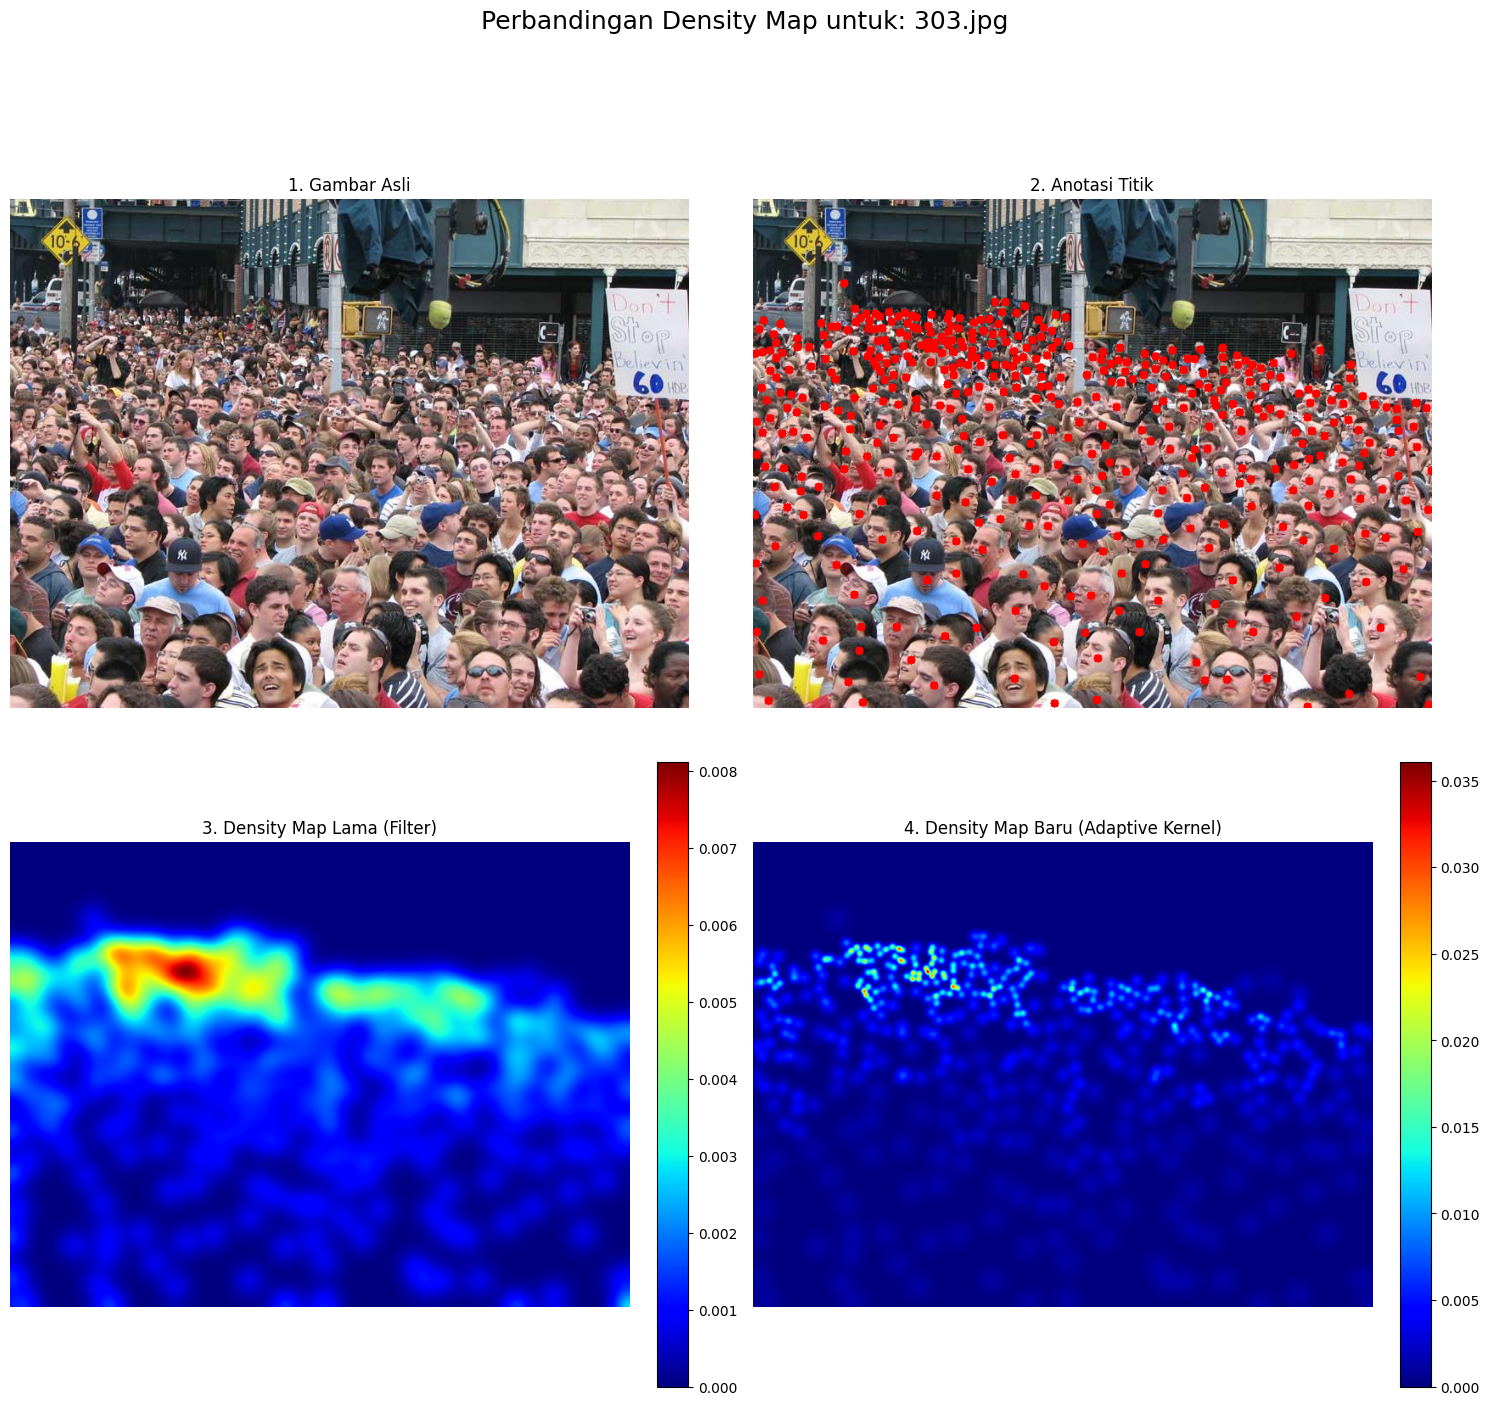

In [21]:
# @title Perbandingan Density Map Biasa dan Gaussian
# --- Import library yang dibutuhkan ---
import matplotlib.pyplot as plt
import random
import os
import json
import cv2
import numpy as np
import math
from scipy.spatial import cKDTree

# --- [SKRIP VISUALISASI UTAMA] ---
print("🔬 Memulai proses verifikasi dan perbandingan density map...")
label_files = [f for f in os.listdir(LBL_DIR) if f.endswith('.json')]
if not label_files: raise FileNotFoundError(f"Tidak ada file .json ditemukan di: {LABEL_DIR}")
random_label_file = random.choice(label_files)
label_path = os.path.join(LBL_DIR, random_label_file)
print(f"File yang dipilih: {random_label_file}")

with open(label_path, 'r') as f: data = json.load(f)
img_id = data['img_id']
points_list_of_dicts = data['points'] # Format: list of dicts
img_path = os.path.join(IMG_DIR, img_id)
image_bgr = cv2.imread(img_path)
if image_bgr is None: raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")

# --- Persiapan data untuk plotting dan fungsi ---
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_for_dots = image_rgb.copy()
points_np = np.array([[p['x'], p['y']] for p in points_list_of_dicts], dtype=np.float32) # Format: numpy array
for x, y in points_np.astype(int):
    cv2.circle(image_for_dots, (x, y), radius=5, color=(255, 0, 0), thickness=-1)

# --- Generate KEDUA Density Map ---
h, w = image_bgr.shape[:2]
# ✨ Panggil FUNGSI LAMA dengan input list of dicts
density_map_old = generate_density_map((h, w), points_list_of_dicts)
# ✨ Panggil FUNGSI BARU dengan input numpy array
density_map_new = generate_gaussian_density(h, w, points_np)

# --- Tampilkan semua hasilnya dalam grid 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle(f'Perbandingan Density Map untuk: {img_id}', fontsize=18)
ax = axes.ravel()

ax[0].imshow(image_rgb); ax[0].set_title('1. Gambar Asli'); ax[0].axis('off')
ax[1].imshow(image_for_dots); ax[1].set_title('2. Anotasi Titik'); ax[1].axis('off')

im3 = ax[2].imshow(density_map_old, cmap='jet'); ax[2].set_title('3. Density Map Lama (Filter)'); ax[2].axis('off')
fig.colorbar(im3, ax=ax[2], fraction=0.046, pad=0.04)

im4 = ax[3].imshow(density_map_new, cmap='jet'); ax[3].set_title('4. Density Map Baru (Adaptive Kernel)'); ax[3].axis('off')
fig.colorbar(im4, ax=ax[3], fraction=0.046, pad=0.04)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Perbandingan dengan Gaussian adaptif (gambar kiri vs kanan)**
- *Point impulse + filter* (kiri) cenderung menghasilkan **heatmap lebih halus** namun bisa **melebar** dan “mencair” di area padat.
- *Gaussian adaptif k-NN* (kanan) memberi **puncak yang tajam** di sekitar titik dengan **σ menyesuaikan jarak tetangga**, sehingga distribusi kepadatan **lebih terlokalisasi** dan **konservasi massa** lebih stabil.

> Ringkasnya: pendekatan **impulse** itu cepat dan sederhana, tetapi untuk crowd counting modern, **Gaussian adaptif** memberi sinyal pembelajaran yang lebih kaya dan stabil.

### **Augmentasi**

Kami menyiapkan dua pipeline `albumentations`:

- **`build_train_tf(patch_size=512)`** — *augmentasi moderat* untuk generalisasi:
  - `RandomResizedCrop(size=(H,W), scale=(0.5,1.0), ratio≈[3/4,4/3])` menjaga variasi skala & aspek tanpa merusak komposisi.
  - `HorizontalFlip(p=0.5)` dan `Rotate(limit=10°, border_mode=CONSTANT)` memberi variasi pose ringan yang masih realistis.
  - `ColorJitter` & `GaussianBlur` meniru kondisi pencahayaan/optik lapangan.
  - `Normalize(mean/std ImageNet)` + `ToTensorV2()` menyelaraskan input dengan backbone (VGG/CSRNet).
  - `keypoint_params=format="xy", remove_invisible=True` memastikan **titik anotasi ikut ter-transform** dan otomatis dibuang jika keluar bidang (penting untuk density-map generator downstream).

- **`build_noaug_tf(patch_size=512)`** — untuk **validasi/inferensi**:
  - `Resize → Normalize → ToTensorV2` tanpa augmentasi, sehingga metrik konsisten & dapat direplikasi.

In [22]:
def build_train_tf(patch_size=512):
    """
    v2: RandomResizedCrop pakai `size=(H, W)`, scale harus di (0,1].
    Rotate kecil biar realistis.
    """
    return A.Compose(
        [
            A.RandomResizedCrop(
                size=(patch_size, patch_size),
                scale=(0.5, 1.0),
                ratio=(0.75, 1.3333),
                p=1.0,
            ),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, border_mode=cv2.BORDER_CONSTANT, value=(0,0,0), p=0.3),
            A.ColorJitter(p=0.3, brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            A.GaussianBlur(blur_limit=(3, 5), p=0.15),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ],
        keypoint_params=A.KeypointParams(format="xy", remove_invisible=True),
    )

def build_noaug_tf(patch_size=512):
    """
    No-augment dengan keypoints konsisten (Resize -> Normalize -> ToTensor).
    """
    return A.Compose(
        [
            A.Resize(height=patch_size, width=patch_size),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ],
        keypoint_params=A.KeypointParams(format="xy", remove_invisible=True),
    )

### **Dataset**
Kami menyiapkan dua dataset untuk kebutuhan **training** dan **validasi** dengan perhatian pada
sinkronisasi **keypoints → density map**.

`CrowdTrainDataset(pairs, patch_size=512, k=3, augment=True)`

- **Tujuan:** memberi model patch berukuran tetap dengan **titik yang sudah ikut di-transform** dan **density map** yang konsisten.
- **Langkah utama:**
  1) **Load** gambar RGB dan titik `(x, y)` dari JSON.  
  2) **Point-biased crop (70%)**: pilih acak salah satu titik sebagai **pusat crop** agar patch kaya sinyal (mengurangi patch kosong).  
     - Koreksi koordinat titik relatif terhadap crop; buang yang keluar patch.  
     - Jika ukuran crop ≠ `patch_size`, **resize** dan **skala** ulang koordinat titik.  
  3) **Albumentations** (`build_train_tf` atau `build_noaug_tf`) dengan `keypoint_params="xy"` sehingga titik ikut rotasi/flip/crop.  
  4) **Generate density setelah augmentasi**:  
     `generate_gaussian_density(H, W, keypoints_aug, k=self.k)` → **Gaussian adaptif k-NN**, lalu `torch.from_numpy(...).unsqueeze(0)` → shape `[1, H, W]`.  
  5) **Keluaran:**  
     - `img_t`: tensor gambar `[3, H, W]`  
     - `dens`: tensor density `[1, H, W]`  
     - `count`: jumlah titik pasca-transform (integer)

`CrowdValDataset(pairs, max_side=1536)`

- **Tujuan:** evaluasi **tanpa augmentasi** dengan skala terkendali dan metadata lengkap untuk pelaporan.
- **Langkah utama:**
  1) **Load** gambar, hitung `gt_count = len(points)`.  
  2) **Resize isotropik** agar sisi terpanjang ≤ `max_side` (menjaga rasio aspek).  
  3) **Normalize** dengan mean/std ImageNet, ubah ke tensor `[3, H, W]`.  
  4) **Keluaran:**  
     - `img_t`: tensor input  
     - `meta`: dict berisi `path`, `orig_size=(h, w)`, `scale`, dan `gt` (ground truth count)


In [23]:
class CrowdTrainDataset(Dataset):
    def __init__(self, pairs, patch_size=512, k=3, augment=True):
        self.pairs = pairs
        self.patch = patch_size
        self.k = k
        self.augment = augment
        self.transform = build_train_tf(patch_size) if augment else build_noaug_tf(patch_size)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ip, jp = self.pairs[idx]

        # load image & points
        img = cv2.imread(ip)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        pts = load_points_from_json(jp)  # np.ndarray (N,2)

        # point-biased manual crop 70% sebelum Albumentations
        if len(pts) > 0 and random.random() < 0.7:
            cx, cy = random.choice(pts).astype(int)
            half = max(64, self.patch // 2)
            x1 = int(np.clip(cx - half, 0, w - 1))
            y1 = int(np.clip(cy - half, 0, h - 1))
            x2 = int(np.clip(x1 + self.patch, 0, w))
            y2 = int(np.clip(y1 + self.patch, 0, h))
            crop = img[y1:y2, x1:x2]

            pts_crop = pts.copy()
            pts_crop[:, 0] -= x1
            pts_crop[:, 1] -= y1
            m = (pts_crop[:, 0] >= 0) & (pts_crop[:, 0] < crop.shape[1]) & \
                (pts_crop[:, 1] >= 0) & (pts_crop[:, 1] < crop.shape[0])
            pts_crop = pts_crop[m]

            if crop.shape[0] != self.patch or crop.shape[1] != self.patch:
                sx = self.patch / max(1, crop.shape[1])
                sy = self.patch / max(1, crop.shape[0])
                crop = cv2.resize(crop, (self.patch, self.patch), interpolation=cv2.INTER_LINEAR)
                if len(pts_crop):
                    pts_crop[:, 0] *= sx
                    pts_crop[:, 1] *= sy

            work_img = crop
            work_pts = pts_crop
        else:
            work_img = img
            work_pts = pts

        Hcur, Wcur = work_img.shape[:2]

        if len(work_pts):
            m_in = (work_pts[:,0] >= 0) & (work_pts[:,0] < Wcur) & \
                  (work_pts[:,1] >= 0) & (work_pts[:,1] < Hcur)
            work_pts = work_pts[m_in]

        if work_img.dtype != np.uint8:
            work_img = np.clip(work_img, 0, 255).astype(np.uint8)


        keyps = [tuple(p) for p in work_pts] if len(work_pts) else []
        aug = self.transform(image=work_img, keypoints=keyps)
        img_t = aug["image"]  # tensor [3,H,W]
        work_pts_aug = np.array(aug["keypoints"], dtype=np.float32) if len(aug["keypoints"]) else np.zeros((0, 2), np.float32)

        # density dari keypoints yang SUDAH ditransform
        Ht, Wt = img_t.shape[1], img_t.shape[2]
        dens = generate_gaussian_density(Ht, Wt, work_pts_aug, k=self.k)
        dens = torch.from_numpy(dens).unsqueeze(0)  # [1,H,W]

        return img_t, dens, int(len(work_pts_aug))


class CrowdValDataset(Dataset):
    def __init__(self, pairs, max_side=1536):
        self.pairs = pairs
        self.max_side = max_side

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        ip, jp = self.pairs[idx]
        img = cv2.imread(ip); img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        pts = load_points_from_json(jp)
        gt_count = len(pts)

        scale = min(1.0, float(self.max_side) / max(h, w))
        nh, nw = int(round(h * scale)), int(round(w * scale))
        img_res = cv2.resize(img, (nw, nh), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0

        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1,1,3)
        std  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1,1,3)
        img_res = (img_res - mean) / std

        img_t = torch.from_numpy(img_res).permute(2, 0, 1).contiguous()
        meta = {"path": ip, "orig_size": (h, w), "scale": scale, "gt": gt_count}
        return img_t, meta

## **MODELLING**

### **Arsitektur Model**

CSRNet terdiri dari 3 layer utama:
1. Frontend
2. Backend
3. Output

In [24]:
from torchvision import models

class CSRNet(nn.Module):
    """
    Front: VGG16 features (conv1_1 ... conv5_3) tanpa pooling terakhir
    Back: dilated conv untuk receptive field besar
    """
    def __init__(self, load_pretrained=True):
        super().__init__()
        vgg = models.vgg16_bn(weights=models.VGG16_BN_Weights.IMAGENET1K_V1 if load_pretrained else None)
        features = list(vgg.features.children())

        # ambil sampai conv5_3 (sebelum maxpool terakhir), buang classifier
        self.frontend = nn.Sequential(*features[:33])  # up to relu4_3 + pool, lalu conv5_x hingga bn? (33 aman)
        # Backend dilated
        self.backend = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(512, 256, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, padding=2, dilation=2), nn.ReLU(inplace=True),
            nn.Conv2d(128, 64,  3, padding=2, dilation=2), nn.ReLU(inplace=True),
        )
        self.output_layer = nn.Conv2d(64, 1, 1)

        # init
        for m in self.backend.children():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
        nn.init.normal_(self.output_layer.weight, std=0.01)
        if self.output_layer.bias is not None:
            nn.init.constant_(self.output_layer.bias, 0)

    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        # density map output (no activation); boleh ReLU untuk non-negativity:
        x = F.relu(x)
        return x


### **Train & Eval Script**

Untuk melatih dan mengevaluasi model, ada beberapa fungsi yang kami buat:
1. `count_from_density`: Mengubah **density map** menjadi **predicted count**:
2. `mae`: Menghitung kesalahan prediksi dengan rumus $\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} \big| \hat{y}_i - y_i \big|$
3. `train_one_epoch`: Menjalankan proses training untuk satu putaran penuh pada dataset (satu *epoch*)

In [ ]:
def count_from_density(dm: torch.Tensor) -> torch.Tensor:
    # Hitung total count dengan menjumlahkan seluruh pixel di density map
    # dm: [B,1,H,W] → output: [B]
    return dm.sum(dim=[1,2,3])

def mae(pred_counts, gt_counts):
    # Hitung Mean Absolute Error antara prediksi count dengan ground truth count
    return torch.mean(torch.abs(pred_counts - gt_counts))

def train_one_epoch(model, loader, optimizer, scaler, device, w_count=0.1,
                    scheduler=None, ema=None, clip_grad_norm=1.0):
    model.train()
    run_loss, run_mae = 0.0, 0.0
    for imgs, dens, gt_counts in tqdm(loader, desc="train", leave=False):
        imgs = imgs.to(device); dens = dens.to(device)
        gt_counts = torch.tensor(gt_counts, dtype=torch.float32, device=device)

        optimizer.zero_grad(set_to_none=True)  # reset grad

        # Mixed Precision Training (hemat memori & lebih cepat di GPU)
        with torch.cuda.amp.autocast(enabled=True):
            pred_dm = model(imgs)  # forward pass → prediksi density map

            # Samakan resolusi GT(Ground Truth) density map dengan prediksi kalau berbeda
            if pred_dm.shape[-2:] != dens.shape[-2:]:
                dens_res = F.interpolate(dens, size=pred_dm.shape[-2:], mode='bilinear', align_corners=False)
            else:
                dens_res = dens

            # Hitung loss utama: Charbonnier Loss (lebih robust daripada MSE)
            eps = 1e-3
            loss_d = torch.mean(torch.sqrt((pred_dm - dens_res)**2 + eps**2))

            # Hitung prediksi jumlah orang dengan menjumlahkan density map
            pred_counts = pred_dm.sum(dim=[1,2,3])

            # Tambahan loss berdasarkan error total count (L1 Loss)
            loss_cnt = F.l1_loss(pred_counts, gt_counts)

            # Tambahan loss error relatif (mengurangi bias di crowd kecil/besar)
            loss_rel = torch.mean(torch.abs(pred_counts - gt_counts) / (gt_counts + 1.0))

            # Total loss = kombinasi density loss + count loss + relative loss
            loss = loss_d + w_count * loss_cnt + 0.05 * loss_rel

        # Backprop dengan Automatic Mixed Precision
        scaler.scale(loss).backward()

        # Gradient clipping (hindari exploding gradient)
        if clip_grad_norm is not None:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)

        scaler.step(optimizer)  # update parameter model
        scaler.update()         # update scaler untuk AMP

        # Update learning rate scheduler (jika ada) per step
        if scheduler is not None:
            scheduler.step()

        # Update Exponential Moving Average (EMA) model (jika ada)
        if ema is not None:
            ema.update(model)

        
        with torch.no_grad():
            run_loss += loss.item() * imgs.size(0)
            run_mae  += torch.sum(torch.abs(pred_counts - gt_counts)).item()

    n = len(loader.dataset)
    return run_loss/n, run_mae/n


`evaluate_full`:
- melakukan evaluasi pada dataset validasi dengan menghitung val_MAE dan val_loss yang formulanya sengaja dibuat konsisten dengan saat training.
- Proses ini fleksibel, di mana untuk density loss dapat dipilih antara Charbonnier loss yang lebih robust (use_charbonnier=True) atau MSE.
- Loss total juga mempertimbangkan count loss dengan bobot yang bisa diatur, yaitu w_count untuk L1 loss pada hitungan absolut dan w_rel untuk hitungan relatif, sehingga memberikan gambaran performa model yang komprehensif pada data yang belum pernah dilihatnya.

In [27]:
@torch.no_grad()
def evaluate_full(model, loader, device, w_count=0.1, w_rel=0.05, use_charbonnier=True, eps=1e-3):
    """
    Evaluasi di val: hitung val_MAE dan val_loss yang konsisten dengan training.
    - use_charbonnier=True -> density loss = Charbonnier (robust). Jika False -> pakai MSE.
    - w_count: bobot L1 pada count absolute
    - w_rel:   bobot relative count (MAE relatif), set 0.0 jika tidak ingin dipakai
    """
    model.eval()
    total_mae, total_loss, n = 0.0, 0.0, 0

    for imgs, dens, gt_counts in tqdm(loader, desc="Validate", leave=False):
        # batch to device
        imgs = imgs.to(device, non_blocking=True)
        dens = dens.to(device, non_blocking=True)
        if isinstance(gt_counts, (list, tuple)):
            gt_counts = torch.tensor(gt_counts, dtype=torch.float32, device=device)
        else:
            gt_counts = gt_counts.to(device, dtype=torch.float32)

        # forward
        pred_dm = model(imgs)

        # samakan resolusi GT density bila perlu
        if pred_dm.shape[-2:] != dens.shape[-2:]:
            dens = F.interpolate(dens, size=pred_dm.shape[-2:], mode='bilinear', align_corners=False)

        # density loss
        if use_charbonnier:
            loss_d = torch.mean(torch.sqrt((pred_dm - dens) ** 2 + eps ** 2))
        else:
            loss_d = F.mse_loss(pred_dm, dens)

        # count losses
        pred_counts = pred_dm.sum(dim=[1, 2, 3])
        loss_cnt = F.l1_loss(pred_counts, gt_counts)

        if w_rel > 0:
            loss_rel = torch.mean(torch.abs(pred_counts - gt_counts) / (gt_counts + 1.0))
            loss = loss_d + w_count * loss_cnt + w_rel * loss_rel
        else:
            loss = loss_d + w_count * loss_cnt

        # akumulasi
        bs = imgs.size(0)
        total_loss += loss.item() * bs
        total_mae  += torch.sum(torch.abs(pred_counts - gt_counts)).item()
        n += bs

    val_mae  = total_mae / max(1, n)
    val_loss = total_loss / max(1, n)
    return val_mae, val_loss

### **Scheduler & EMA**

ini dipake buat setelah dapet base model (yang udah dilatih 25 epoch (dijadikan kayak pretrained))

In [ ]:
import math, copy

class WarmupCosine:
    """
    Pada awal training (sampai warmup_steps), learning rate dinaikkan 
    secara linear dari 0 ke base learning rate.
    """
    def __init__(self, optimizer, warmup_steps, total_steps, base_lr, min_lr=3e-6, start_step=0):
        self.opt = optimizer
        self.warmup_steps = int(warmup_steps)
        self.total_steps  = int(total_steps)
        self.base_lr = base_lr
        self.min_lr  = min_lr
        self.i = int(start_step)  # untuk resume

    def step(self):
        self.i += 1
        if self.i <= self.warmup_steps:
            lr = self.base_lr * self.i / max(1, self.warmup_steps)
        else:
            t = (self.i - self.warmup_steps) / max(1, self.total_steps - self.warmup_steps)
            lr = self.min_lr + 0.5*(self.base_lr - self.min_lr)*(1 + math.cos(math.pi*t))
        for pg in self.opt.param_groups:
            pg["lr"] = lr
        return lr

class ModelEMA:
    """
    Exponential Moving Average (EMA) tujuannya buat bikin salinan model yang lebih stabil 
    dengan tidak melakukan perubahan yang besar
    """
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        for p in self.ema.parameters(): p.requires_grad_(False)
        self.decay = decay

    @torch.no_grad()
    def update(self, model):
        d = self.decay
        for p_ema, p in zip(self.ema.parameters(), model.parameters()):
            p_ema.data.mul_(d).add_(p.data, alpha=1.0 - d)

    def state_dict(self):
        return self.ema.state_dict()


### **Checkpoint Training**

proses training bisa memakan waktu **berjam-jam**. Untuk itu, kami membuat **checkpointing** sebagai berikut:
1. `save_ckpt`

- Menyimpan **checkpoint lengkap** model, optimizer, scaler, epoch, best MAE, scheduler step (opsional), dan EMA state (opsional).  
- Membuat folder tujuan jika belum ada.  
- Struktur payload yang disimpan:  

2. `load_ckpt`
- Memuat checkpoint dari file dan mengembalikan start_epoch, best_mae, dan sched_step.
- Memulihkan state_dict model, optimizer, dan scaler.
- Jika ada EMA dan objek ema diberikan, memuat state EMA.
- Menangani kasus field yang tidak ada atau gagal load EMA dengan warning.

In [28]:
def save_ckpt(path, model, optimizer, scaler, epoch, best_mae, sched_step=None, ema_state=None):
    """
    Simpan last checkpoint lengkap. ema_state opsional (kalau None, field 'ema' tidak disimpan).
    """
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "scaler": scaler.state_dict() if scaler is not None else None,
        "epoch": epoch,
        "best_mae": best_mae,
    }
    if sched_step is not None:
        payload["sched_step"] = int(sched_step)
    if ema_state is not None:
        payload["ema"] = ema_state
    torch.save(payload, path)

def load_ckpt(path, model, optimizer, scaler, device, ema=None):
    ckpt = torch.load(path, map_location=device)

    model.load_state_dict(ckpt["model"])
    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])
    if scaler is not None and ckpt.get("scaler") is not None:
        scaler.load_state_dict(ckpt["scaler"])

    # kalau ada EMA di ckpt & kamu kirim objek ema, apply ke ema.ema
    if ema is not None and "ema" in ckpt:
        try:
            ema.ema.load_state_dict(ckpt["ema"])
            print("✔️ EMA state loaded from checkpoint")
        except Exception as e:
            print(f"[WARN] gagal load EMA (abaikan jika arsitektur berubah): {e}")

    start_epoch = ckpt.get("epoch", 0) + 1
    best_mae    = ckpt.get("best_mae", 1e9)
    sched_step  = ckpt.get("sched_step", 0)
    print(f"✅ Resumed from {path} at epoch {start_epoch-1} (best_mae={best_mae:.3f})")
    return start_epoch, best_mae, sched_step

## **Training**

### First Train (Ini yang sebagai model baseline)

In [ ]:
# Split
all_ids = [int(Path(p[0]).stem) for p in pairs]
train_pairs, val_pairs = train_test_split(pairs, test_size=0.1, random_state=SEED)

# Datasets & loaders
BATCH = 16
train_ds = CrowdTrainDataset(train_pairs, patch_size=512, k=3, augment=True)
val_ds   = CrowdValDataset(val_pairs, max_side=1536)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=2, pin_memory=True)

# Val untuk hitung val_loss + val_mae (tanpa augment, patch lebih besar sedikit biar stabil)
val_eval_ds = CrowdTrainDataset(val_pairs, patch_size=768, k=3, augment=False)
val_eval_loader = DataLoader(val_eval_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

# Model/optim
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CSRNet(load_pretrained=True).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(device=="cuda"))

EPOCHS = 25
best_mae, best_path = 1e9, f"{OUT_DIR}/csrnet_best.pt"

Downloading: "https://download.pytorch.org/models/vgg16_bn-6c64b313.pth" to /root/.cache/torch/hub/checkpoints/vgg16_bn-6c64b313.pth


100%|██████████| 528M/528M [00:05<00:00, 94.2MB/s]


In [ ]:
LAST_CKPT = f"{OUT_DIR}/last_ckpt.pt"
for epoch in range(1, EPOCHS+1):
    tr_loss, tr_mae = train_one_epoch(model, train_loader, optimizer, scaler, device, w_count=0.1)
    val_mae, val_loss = evaluate_full(model, val_eval_loader, device, w_count=0.1)

    print(f"Epoch {epoch:03d} | train_loss {tr_loss:.4f} | train_MAE {tr_mae:.2f} | val_MAE {val_mae:.2f}")
    # simple cosine decay
    lr = 1e-4 * (0.5 * (1 + math.cos(math.pi * epoch / EPOCHS)))
    for pg in optimizer.param_groups: pg['lr'] = lr

    if val_mae < best_mae:
        best_mae = val_mae
        torch.save({"model": model.state_dict()}, best_path)
        print(f"  👉 saved best to {best_path} (MAE={best_mae:.2f})")

    save_ckpt(LAST_CKPT, model, optimizer, scaler, epoch, best_mae)

Epoch 001 | train_loss 4.7082 | train_MAE 47.03 | val_MAE 103.92
  👉 saved best to ./outputs/csrnet_best.pt (MAE=103.92)


Epoch 002 | train_loss 3.8508 | train_MAE 38.42 | val_MAE 51.20
  👉 saved best to ./outputs/csrnet_best.pt (MAE=51.20)


Epoch 003 | train_loss 3.2853 | train_MAE 32.77 | val_MAE 73.88


Epoch 004 | train_loss 3.1794 | train_MAE 31.70 | val_MAE 86.15


Epoch 005 | train_loss 2.5381 | train_MAE 25.32 | val_MAE 55.00


...

Epoch 021 | train_loss 1.2173 | train_MAE 12.11 | val_MAE 24.42
  👉 saved best to ./outputs/csrnet_best.pt (MAE=24.42)


Epoch 022 | train_loss 1.0761 | train_MAE 10.71 | val_MAE 28.62


Epoch 023 | train_loss 1.0835 | train_MAE 10.79 | val_MAE 28.42


Epoch 024 | train_loss 0.9579 | train_MAE 9.53 | val_MAE 26.78


Epoch 025 | train_loss 1.0109 | train_MAE 10.06 | val_MAE 27.13


### Lanjut Ekperiment dari model base

eksperimen terhadap lr, batch, image_size

Set Up ulang

In [29]:
# --- Split ---
all_ids = [int(Path(p[0]).stem) for p in pairs]
train_pairs, val_pairs = train_test_split(pairs, test_size=0.1, random_state=SEED)

# --- Datasets & loaders ---
BATCH = 8
train_ds = CrowdTrainDataset(train_pairs, patch_size=512, k=3, augment=True)

# Loader train: kalau sempat ada hang, turunin num_workers=0 dulu
train_loader = DataLoader(
    train_ds, batch_size=BATCH, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,
    persistent_workers=True
)

# Val untuk hitung val_loss + val_mae
val_eval_ds = CrowdTrainDataset(val_pairs, patch_size=768, k=3, augment=False)
val_eval_loader = DataLoader(val_eval_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

# --- Model/optim ---
torch.backends.cudnn.benchmark = True
DEVICE =  "cuda" if torch.cuda.is_available() else "cpu"
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

Finetuning dengan weight pretrained model baseline sebelumnya, menggunakan discriminative learning rate (frontend lebih kecil dari backend), serta mengoptimalkan dengan AdamW + Warmup Cosine scheduler. Model juga distabilkan dengan Exponential Moving Average (EMA), dilengkapi mekanisme early stopping dan penyimpanan checkpoint terbaik maupun terakhir untuk menjaga hasil training.

In [ ]:
LAST_CKPT = f"{OUT_DIR}/last_ckpt_7.pt"       # path checkpoint terakhir (untuk resume training)
BEST_CKPT = f"{OUT_DIR}/csrnet_best_finetuned_2_8batch.pt"  # path checkpoint terbaik (val MAE terendah)

model = CSRNet(load_pretrained=True).to(DEVICE)  # inisialisasi model CSRNet dengan pretrained VGG 

# 1) Load model weights dari checkpoint lama
ckpt_old = torch.load(f"./outputs/csrnet_best_submited.pt", map_location=device)
model.load_state_dict(ckpt_old["model"] if "model" in ckpt_old else ckpt_old)

# 2) Setup optimizer dengan discriminative LR
#    frontend (VGG) → LR lebih kecil, backend → LR lebih besar
front_ids, back_ids = [], []
for n, p in model.named_parameters():
    (front_ids if "frontend" in n else back_ids).append(p)

optimizer = torch.optim.AdamW(
    [{"params": front_ids, "lr": 1e-6},   # frontend: LR kecil
     {"params": back_ids,  "lr": 2e-5}], # backend: LR lebih besar
    weight_decay=5e-5
)

# Scheduler cosine annealing + warmup
steps_per_epoch = len(train_loader)  
finetune_epochs = 25
total_steps = finetune_epochs * steps_per_epoch
sched = WarmupCosine(optimizer, warmup_steps=1000, total_steps=total_steps,
                     base_lr=2e-5, min_lr=2e-6)

# 3) Exponential Moving Average (EMA) untuk stabilkan parameter model
ema = ModelEMA(model, decay=0.999)

best_mae = 1e9        # inisialisasi best MAE
start_epoch = 1       # epoch awal
bad = 0               # counter stagnasi (untuk early stopping)
patience = 7          # berhenti jika 7 epoch berturut-turut tidak improve

# Resume training jika ada checkpoint terakhir
if os.path.exists(LAST_CKPT):
    start_epoch, best_mae, sched.i = load_ckpt(LAST_CKPT, model, optimizer, scaler, device)
else:
    print("🆕 Fresh training run")

# Loop training + evaluasi
for epoch in range(start_epoch, finetune_epochs+1):
    tr_loss, tr_mae = train_one_epoch(
        model, train_loader, optimizer, scaler, device, w_count=0.1,
        scheduler=sched, ema=ema, clip_grad_norm=1.0
    )
    val_mae, val_loss = evaluate_full(model, val_eval_loader, device, w_count=0.1)

    print(f"[FT] Epoch {epoch:02d} | train_loss {tr_loss:.4f} | train_MAE {tr_mae:.2f} | "
          f"val_loss {val_loss:.4f} | val_MAE {val_mae:.2f}")

    # Simpan model terbaik (berdasarkan MAE val terendah)
    if val_mae + 1e-6 < best_mae:
        best_mae = val_mae; bad = 0
        torch.save({"model": model.state_dict()}, BEST_CKPT)
        print(f"  ✅ best saved (MAE={best_mae:.3f})")
    else:
        bad += 1
        if bad >= patience:   # early stopping jika tidak ada peningkatan
            print("⏹️ early stop (no improvement)"); break

    # Simpan checkpoint terakhir tiap epoch
    save_ckpt(LAST_CKPT, model, optimizer, scaler, epoch, best_mae, sched_step=sched.i)


### **Predict**

In [ ]:
# === Inference → submission.csv ===
import os, glob, csv, math
from pathlib import Path
import numpy as np
import cv2
import torch
import torch.nn.functional as F
from tqdm import tqdm

# ==== CONFIG ====
TEST_IMG_DIR = "./data/test/images"
OUT_DIR = "./outputs"
os.makedirs(OUT_DIR, exist_ok=True)
SUBMIT_CSV = f"{OUT_DIR}/submission_4.csv"

BEST_CKPT = f"{OUT_DIR}/csrnet_best_finetuned_2_8batch.pt"   # ganti jika path mu berbeda
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ==== LOAD MODEL ====
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model = CSRNet(load_pretrained=False).to(DEVICE)
model.load_state_dict(ckpt["model"] if "model" in ckpt else ckpt)
model.eval()

# ==== Normalization (sama seperti training) ====
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32).reshape(1,1,3)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32).reshape(1,1,3)

In [ ]:
def _to_tensor_normalized(img_rgb_f32_01):
    x = (img_rgb_f32_01 - IMAGENET_MEAN) / IMAGENET_STD
    x = torch.from_numpy(x).permute(2,0,1).unsqueeze(0).contiguous()  # [1,3,H,W]
    return x

@torch.no_grad()
def count_from_density(dm: torch.Tensor) -> torch.Tensor:
    # dm: [B,1,H,W]
    return dm.sum(dim=[1,2,3])

@torch.no_grad()
def predict_count_single_tta(
    model, img_rgb_u8,
    scales=(0.8, 1.0, 1.25),
    max_side_infer=2048,
    do_flip=True,
):
    """
    img_rgb_u8: np.uint8 [H,W,3] RGB
    TTA: resize (base capped by max_side_infer), optional flip; rata-rata count.
    """
    h, w = img_rgb_u8.shape[:2]
    base_scale = min(1.0, max_side_infer / max(h, w))
    counts = []

    for s in scales:
        s_eff = base_scale * s
        nh, nw = max(1, int(round(h*s_eff))), max(1, int(round(w*s_eff)))
        img_rs = cv2.resize(img_rgb_u8, (nw, nh), interpolation=cv2.INTER_LINEAR).astype(np.float32) / 255.0

        x = _to_tensor_normalized(img_rs).to(DEVICE)  # [1,3,nh,nw]
        pred = model(x)                                # [1,1,h',w']
        c = count_from_density(pred).item()
        counts.append(c)

        if do_flip:
            xf = torch.flip(x, dims=[-1])             # horizontal flip
            predf = model(xf)
            cf = count_from_density(predf).item()
            counts.append(cf)

    return float(np.mean(counts))


In [ ]:
# ==== RUN ALL TEST IMAGES ====
img_paths = sorted(glob.glob(os.path.join(TEST_IMG_DIR, "*.jpg")))
assert len(img_paths) > 0, f"Tidak menemukan *.jpg di {TEST_IMG_DIR}"

results = []
for ip in tqdm(img_paths, desc="Predict"):
    img = cv2.imread(ip)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pred_c = predict_count_single_tta(
        model, img,
        scales=(0.8, 1.0, 1.25),
        max_side_infer=2048,
        do_flip=True,
    )
    # submission biasanya integer; clamp ke >=0
    pred_int = int(max(0, round(pred_c)))
    results.append((os.path.basename(ip), pred_int))

# ==== WRITE CSV ====
with open(SUBMIT_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["image_id", "predicted_count"])
    for name, cnt in results:
        w.writerow([name, cnt])

print(f"✅ Saved submission to: {SUBMIT_CSV}")
print("Preview 5 baris pertama:")
print("\n".join([f"{n},{c}" for n,c in results[:5]]))

Predict: 100%|██████████| 500/500 [18:25<00:00,  2.21s/it]

✅ Saved submission to: ./outputs/submission_4_finetuned_sub_1.csv
Preview 5 baris pertama:
1.jpg,17
10.jpg,58
100.jpg,157
101.jpg,6
102.jpg,748
